In [2]:
# CNN : 개 / 고양이 이미지(고해상도) 분류 - 이진분류
# pip install tensorflow_datasets


In [3]:
from typing import Sequence
import os, shutil   # 파일/폴더를 이동, 복사, 삭제할 때 사용. 예)shutil.copy('a.txt', 'b.txt')
import tensorflow_datasets as tfds
print(tfds.list_builders())

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

np.random.seed(1)
tf.random.set_seed(1)


['abstract_reasoning', 'accentdb', 'aeslc', 'aflw2k3d', 'ag_news_subset', 'ai2_arc', 'ai2_arc_with_ir', 'ai2dcaption', 'aloha_mobile', 'amazon_us_reviews', 'anli', 'answer_equivalence', 'arc', 'asimov_dilemmas_auto_val', 'asimov_dilemmas_scifi_train', 'asimov_dilemmas_scifi_val', 'asimov_injury_val', 'asimov_multimodal_auto_val', 'asimov_multimodal_manual_val', 'asqa', 'asset', 'assin2', 'asu_table_top_converted_externally_to_rlds', 'austin_buds_dataset_converted_externally_to_rlds', 'austin_sailor_dataset_converted_externally_to_rlds', 'austin_sirius_dataset_converted_externally_to_rlds', 'bair_robot_pushing_small', 'bc_z', 'bccd', 'beans', 'bee_dataset', 'beir', 'berkeley_autolab_ur5', 'berkeley_cable_routing', 'berkeley_fanuc_manipulation', 'berkeley_gnm_cory_hall', 'berkeley_gnm_recon', 'berkeley_gnm_sac_son', 'berkeley_mvp_converted_externally_to_rlds', 'berkeley_rpt_converted_externally_to_rlds', 'big_patent', 'bigearthnet', 'billsum', 'binarized_mnist', 'binary_alpha_digits', 'b

In [4]:
# data download
(dataset, info) = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True) # as_supervise: data를 image를 반환
print(dataset)
print(info)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.UX1U64_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
{Split('train'): <_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>}
tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuf

label_names :  ['cat', 'dog']
dict_keys([Split('train')])
(493, 500, 3) <dtype: 'uint8'>
1


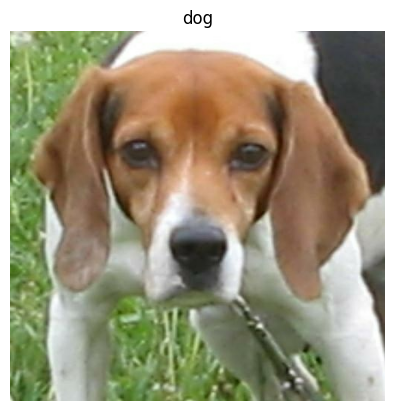

In [5]:
label_names = info.features['label'].names
print('label_names : ', label_names)  # ['cat', 'dog']
print(dataset.keys()) # train만 지원
for image,label in dataset['train'].skip(2).take(1):
  print(image.shape, image.dtype)
  print(label.numpy())
  plt.imshow(image)
  plt.title(label_names[label.numpy()])
  plt.axis('off')
  plt.show()

In [6]:
# 폴더 구조 생성
base_dir = './cats_and_dogs_filtered' # 이미지 루트 폴더
train_dir = os.path.join(base_dir, 'train') # 학습 폴더
validation_dir = os.path.join(base_dir, 'validation') # 검증 폴더

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
val_cats_dir = os.path.join(validation_dir, 'cats')
val_dogs_dir = os.path.join(validation_dir, 'dogs')

for d in [train_cats_dir, train_dogs_dir, val_cats_dir, val_dogs_dir]:
  os.makedirs(d, exist_ok=True)

# train / validation 분할 + 이미지 저장
IMG_SIZE = (150, 150)

def save_imageFunc(img, label, idx, split):
  img = tf.image.resize(img, IMG_SIZE)
  img = tf.cast(img, tf.uint8).numpy()  # tensor를 정수형 이미지로 변환 numpy 배열로 반환. 예) 0.12 -> 0, 255.0 -> 255

  if split == 'train':
    folder = train_cats_dir if label == 0 else train_dogs_dir
  else:
    folder = val_cats_dir if label == 0 else val_dogs_dir

  path = os.path.join(folder, f'{idx}.jpg')
  tf.keras.preprocessing.image.save_img(path, img)    # 이미지가 해당 경로에 저장

# train data의 일부를 validation으로 사용 (8:2)
total = info.splits['train'].num_examples
print(total)  # 23262

train_size = int(0.8  * total)
print(train_size) # 18609

for i,(img, label) in enumerate(dataset['train']):
    if i < train_size:
      save_imageFunc(img, label, i, 'train')
    else:
      save_imageFunc(img, label, i, 'val')

print('데이터 준비 완료~~~')

23262
18609
데이터 준비 완료~~~


In [7]:
PATH = './cats_and_dogs_filtered' # 이미지 루트 폴더
train_dir = os.path.join(PATH, 'train') # 학습 폴더
validation_dir = os.path.join(PATH, 'validation') # 검증 폴더

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
val_cats_dir = os.path.join(validation_dir, 'cats')
val_dogs_dir = os.path.join(validation_dir, 'dogs')

for p in [train_dir, train_cats_dir, train_dogs_dir,validation_dir, val_cats_dir,val_dogs_dir]:
  print(p, "->", os.path.exists(p)) # 경로 확인 유무

print('cats(train):', len(os.listdir(train_cats_dir)), '| dogs(train):', len(os.listdir(train_dogs_dir)))
print('cats(val):', len(os.listdir(val_cats_dir)), '| dogs(val):', len(os.listdir(val_dogs_dir)))


./cats_and_dogs_filtered/train -> True
./cats_and_dogs_filtered/train/cats -> True
./cats_and_dogs_filtered/train/dogs -> True
./cats_and_dogs_filtered/validation -> True
./cats_and_dogs_filtered/validation/cats -> True
./cats_and_dogs_filtered/validation/dogs -> True
cats(train): 9381 | dogs(train): 9228
cats(val): 2277 | dogs(val): 2376


In [8]:
# 참고 : colab에서 폴더 전체를 내 PC로 다운로드하기
import shutil
from google.colab import  files

# 폴더를 zip 파일로 압축
shutil.make_archive(
    "cats_and_dogs_filtered", # 생성될 zip 파일 이름
    "zip",                    # 압축 형식
    "cats_and_dogs_filtered"  # 압축할 폴더명
)

files.download('cats_and_dogs_filtered.zip')  # 내 PC로 다운로드

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# 이미지 증강/스케일링
IMG_HEIGHT, IMG_WIDTH = 150, 150
BATCH_SIZE = 128
EPOCHS = 20 # 실제는 더 큰 수 사용

train_datagen = ImageDataGenerator(
    rescale=1./255,   # [0., 1]
    rotation_range=15, # 회전
    width_shift_range=0.1, height_shift_range=0.1, # 평행이동
    horizontal_flip=True  # 좌우반전
)

val_datagen = ImageDataGenerator(rescale=1./255)  # 검증은 스케일만

train_data = train_datagen.flow_from_directory(   # 폴더를 자동 라벨링하여 로드
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(   # 폴더를 자동 라벨링하여 로드
    validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("class_indices:", train_data.class_indices) # class_indices: {'cats': 0, 'dogs': 1}

Found 18609 images belonging to 2 classes.
Found 4653 images belonging to 2 classes.
class_indices: {'cats': 0, 'dogs': 1}


idx_to_name :  {0: 'cats', 1: 'dogs'}


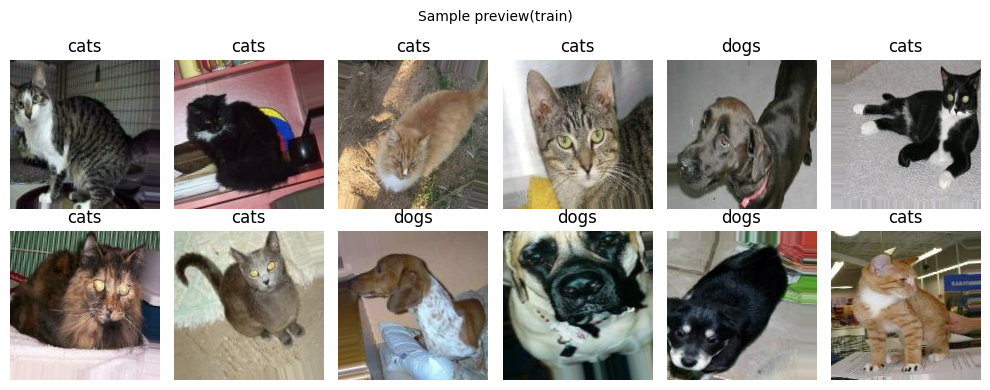

In [14]:
# 로드된 이미지 미리보기 (한 배치)
imgs, labels = next(train_data)
n_show = min(12, imgs.shape[0]) # 보여준 샘플 수
cols = 6
rows = int(np.ceil(n_show / cols))  # 행수

idx_to_name = {v:k for k,v in train_data.class_indices.items()}
print('idx_to_name : ', idx_to_name) #  {0: 'cats', 1: 'dogs'}

plt.figure(figsize=(10, 2 * rows))
for i in range(n_show):
  ax = plt.subplot(rows, cols, i + 1)
  ax.imshow(imgs[i])
  ax.set_title(f'{idx_to_name[int(labels[i])]}')
  ax.axis('off')

plt.suptitle('Sample preview(train)', fontsize=10)
plt.tight_layout()
plt.show()

In [15]:
# model
model = Sequential([
    Input((IMG_HEIGHT, IMG_WIDTH, 3)),
    Conv2D(16, 3, padding='same', activation='relu'),
    MaxPooling2D(),  # featuremap의 절반 크기로 다운샘플링

    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,641,441 (40.59 MB)

 Trainable params: 10,641,441 (40.59 MB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

os.makedirs('chkpoint', exist_ok=True)
ckpt = ModelCheckpoint(
    filepath = 'chkpoints/catdog_best.keras',
    monitor = 'val_accuracy',
    mode = 'max',
    save_best_only = True,
    verbose= 1
)
es = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

history = model.fit(
    train_data, epochs=EPOCHS, validation_data=val_data,
    callbacks = [es, ckpt], verbose= 2
)

Epoch 1/20

Epoch 1: val_accuracy improved from None to 0.72190, saving model to chkpoints/catdog_best.keras

Epoch 1: finished saving model to chkpoints/catdog_best.keras
146/146 - 133s - 913ms/step - accuracy: 0.5880 - loss: 0.6980 - val_accuracy: 0.7219 - val_loss: 0.5601
Epoch 2/20

Epoch 2: val_accuracy improved from 0.72190 to 0.74318, saving model to chkpoints/catdog_best.keras

Epoch 2: finished saving model to chkpoints/catdog_best.keras
146/146 - 115s - 789ms/step - accuracy: 0.7072 - loss: 0.5685 - val_accuracy: 0.7432 - val_loss: 0.5217
Epoch 3/20

Epoch 3: val_accuracy improved from 0.74318 to 0.77434, saving model to chkpoints/catdog_best.keras

Epoch 3: finished saving model to chkpoints/catdog_best.keras
146/146 - 114s - 784ms/step - accuracy: 0.7459 - loss: 0.5178 - val_accuracy: 0.7743 - val_loss: 0.4667
Epoch 4/20

Epoch 4: val_accuracy improved from 0.77434 to 0.77799, saving model to chkpoints/catdog_best.keras

Epoch 4: finished saving model to chkpoints/catdog_be

검증 평가 결과 : acc : 0.8790 , loss : 0.2933


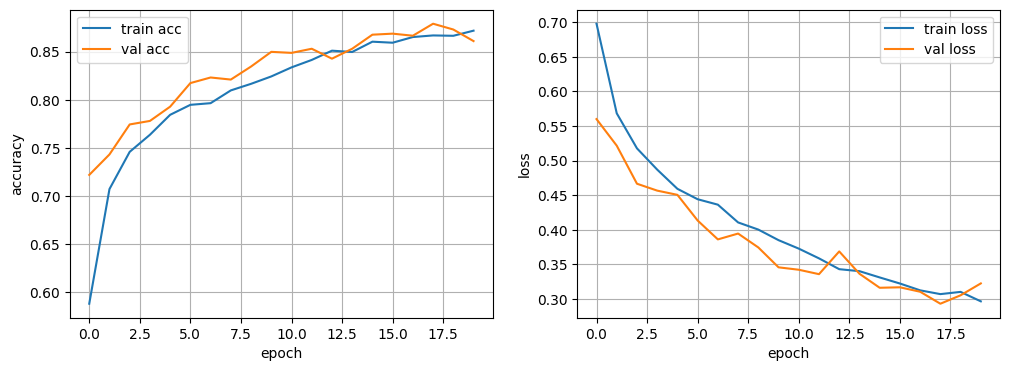

In [18]:
# 평가 / 시각화
val_loss, val_acc = model.evaluate(val_data, verbose=0)
print(f'검증 평가 결과 : acc : {val_acc:.4f} , loss : {val_loss:.4f}')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()

Found 4653 images belonging to 2 classes.


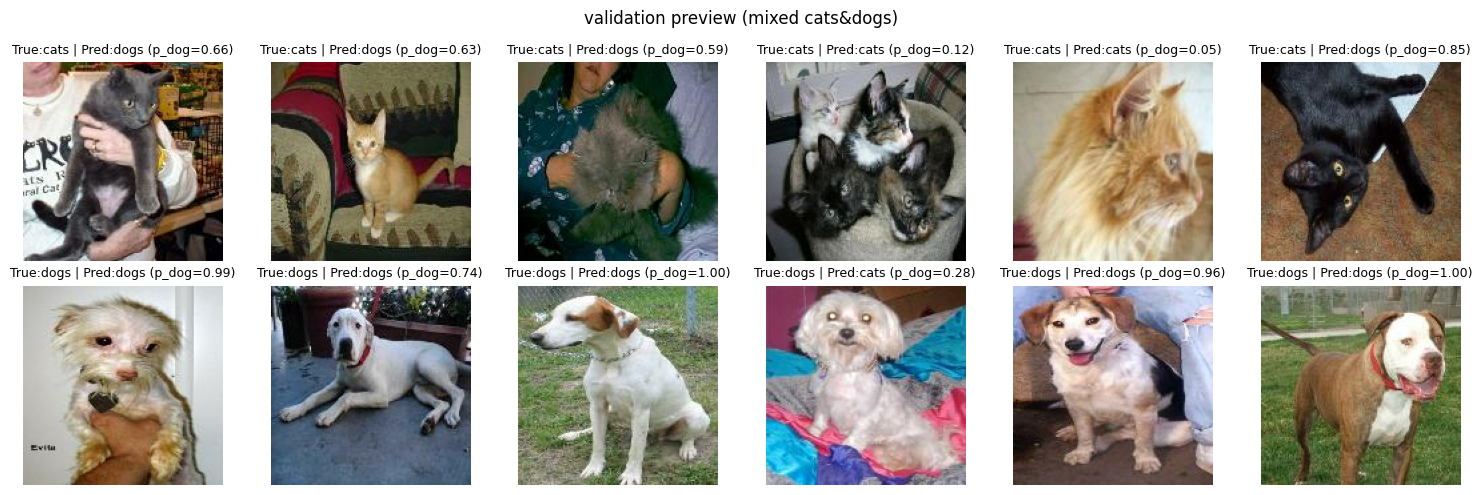

In [21]:
# 검증 배치 예측 확인
preview_gen = ImageDataGenerator(rescale=1./255)

# 미리보기 전용 : 섞어서 배치 뽑기 (평가용 val_data는 그대로 유지)
preview_flow = preview_gen.flow_from_directory(
    validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=123
)

# 예측용 개/고양이 보기(6개)
n_each = 6    # 개/고양이 각각 n개를 모을 때 까지 여러 배치 이어받기

cats_images, dogs_images = [], []

while len(cats_images) < n_each or len(dogs_images) < n_each:
  imgs, labels = next(preview_flow)

  for im, lb in zip(imgs, labels.ravel()):   # 배치 안에서 이미지 하나씩 살펴보면 cats/dogs 리스트에 채우기
    if lb == 0 and len(cats_images) < n_each:
      cats_images.append(im)
    elif lb == 1 and len(dogs_images) < n_each:
      dogs_images.append(im)

    if len(cats_images) >= n_each and len(dogs_images) >= n_each:
      break

# 예측
cats_probs = model.predict(np.array(cats_images), verbose=0).ravel()
dogs_probs = model.predict(np.array(dogs_images), verbose=0).ravel()

# 예측 결과 시각화(0행: 고양이, 1행:개)
rows, cols = 2, n_each
plt.figure(figsize=(2.5 * cols, 5))

for i in range(n_each):
  # cats row
  ax = plt.subplot(rows, cols, i + 1)
  ax.imshow(cats_images[i])
  ax.axis('off')
  p = cats_probs[i]
  ax.set_title(f"True:cats | Pred:{'dogs' if p >= 0.5 else 'cats'} (p_dog={p:.2f})", fontsize=9)

  # dogs row
  ax = plt.subplot(rows, cols, cols + i + 1)
  ax.imshow(dogs_images[i])
  ax.axis('off')
  p = dogs_probs[i]
  ax.set_title(f"True:dogs | Pred:{'dogs' if p >= 0.5 else 'cats'} (p_dog={p:.2f})", fontsize=9)

plt.suptitle('validation preview (mixed cats&dogs)', fontsize=12)
plt.tight_layout()
plt.show()